In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
color_pal=sns.color_palette()
plt.style.use('fivethirtyeight')
import xgboost as xgb
#df=pd.read_csv('/content/PJMW_hourly.csv')
df=pd.read_csv('/content/drive/MyDrive/Breakdown Predictive Model/PJMW_hourly.csv')
df=df.set_index('Datetime')
df.index=pd.to_datetime(df.index)
df.head()

,PJMW_MW
Datetime,
2002-12-31 01:00:00,5077.0
2002-12-31 02:00:00,4939.0
2002-12-31 03:00:00,4885.0
2002-12-31 04:00:00,4857.0
2002-12-31 05:00:00,4930.0


<Axes: title={'center': 'PJMW Hourly Energy Consumption'}, xlabel='Datetime'>

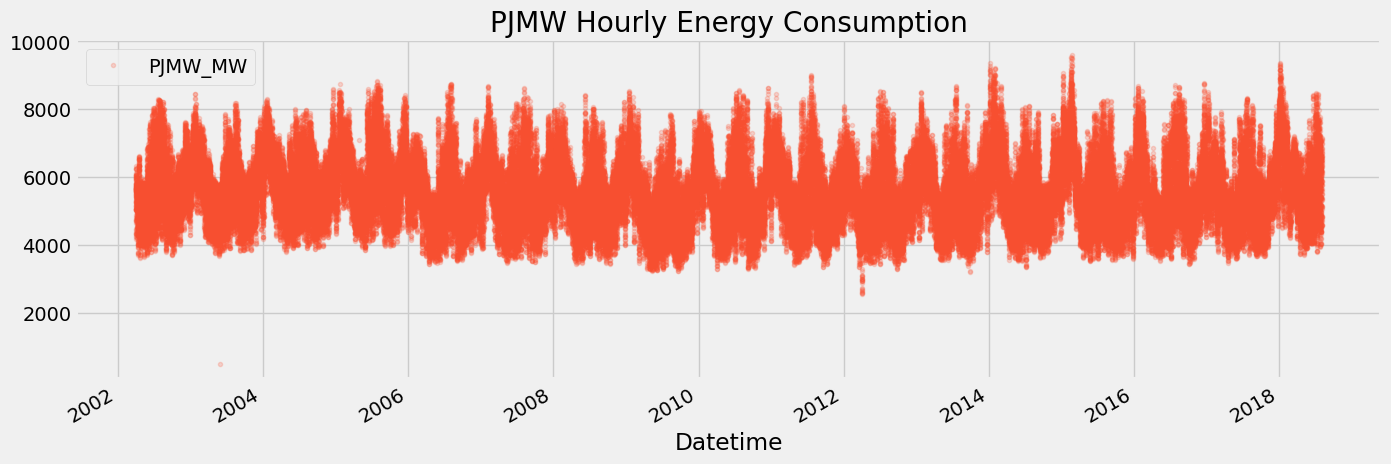

In [50]:
#import matplotlib.pyplot as plt
df.plot(style='.',figsize=(15,5),alpha=0.2,color=color_pal[1],title='PJMW Hourly Energy Consumption')

#Train/Test Split

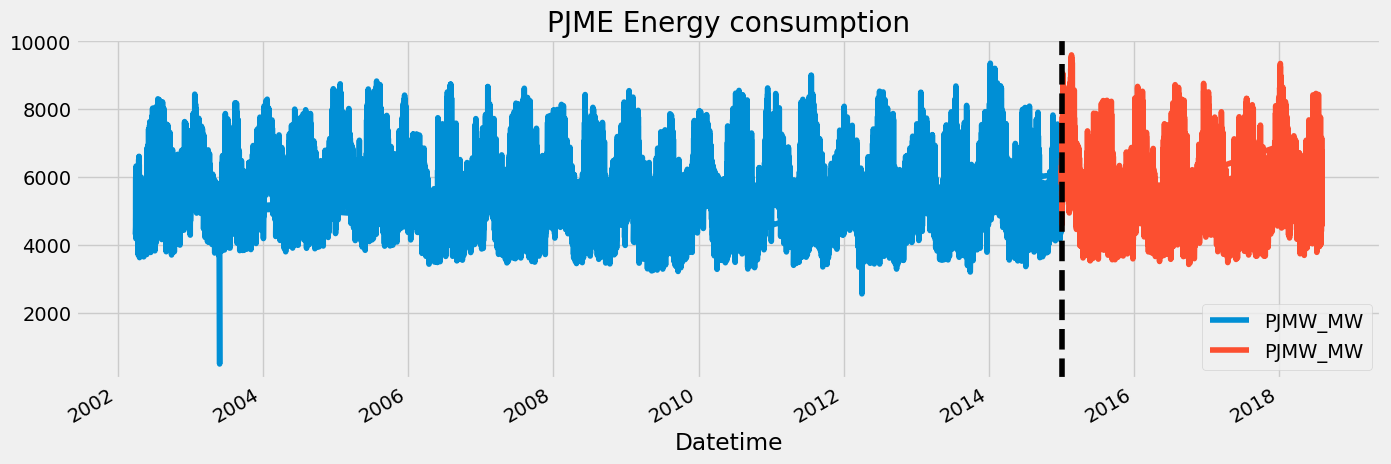

In [51]:
train=df.loc[df.index < '01-01-2015'].copy()
test=df.loc[df.index >= '01-01-2015'].copy()

fig,ax=plt.subplots(figsize=(15,5))
train.plot(ax=ax,label='Train Set',title='PJME Energy consumption')
test.plot(ax=ax,label='Test Set')
ax.axvline('01-01-2015',color='black',ls='--')
#ax.legend(['Train Set','Test Set'])
plt.show()

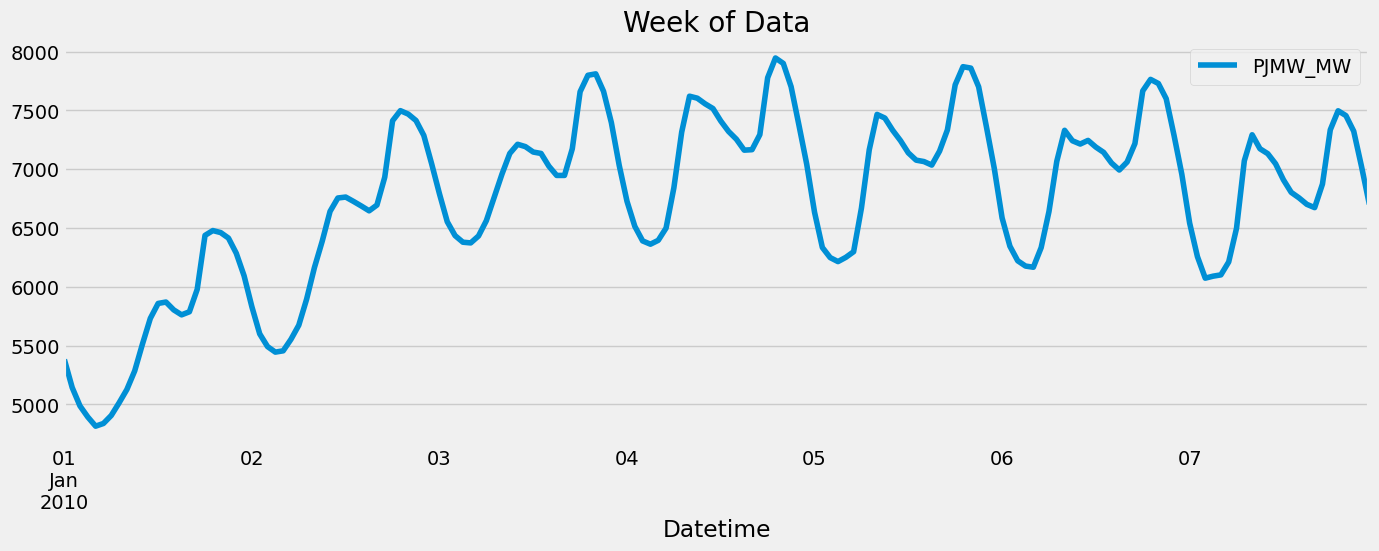

In [52]:
df = df.sort_index()
df.loc[(df.index >= '01-01-2010') & (df.index < '01-08-2010')].plot(figsize=(15,5),kind='line',title='Week of Data')
plt.show()

#Features Selection

In [53]:
def Create_Features(df):
  df=df.copy()
  df['Hour']=df.index.hour
  df['Dayofweek']=df.index.dayofweek
  df['Dayofyear']=df.index.dayofyear
  df['Month']=df.index.month
  df['Quarter']=df.index.quarter
  df['Year']=df.index.year
  return df
df=Create_Features(df)
df

,PJMW_MW,Hour,Dayofweek,Dayofyear,Month,Quarter,Year
Datetime,,,,,,,
2002-04-01 01:00:00,4374.0,1,0,91,4,2,2002
2002-04-01 02:00:00,4306.0,2,0,91,4,2,2002
2002-04-01 03:00:00,4322.0,3,0,91,4,2,2002
2002-04-01 04:00:00,4359.0,4,0,91,4,2,2002
2002-04-01 05:00:00,4436.0,5,0,91,4,2,2002
...,...,...,...,...,...,...,...
2018-08-02 20:00:00,6545.0,20,3,214,8,3,2018
2018-08-02 21:00:00,6496.0,21,3,214,8,3,2018
2018-08-02 22:00:00,6325.0,22,3,214,8,3,2018


#Features Vizualization

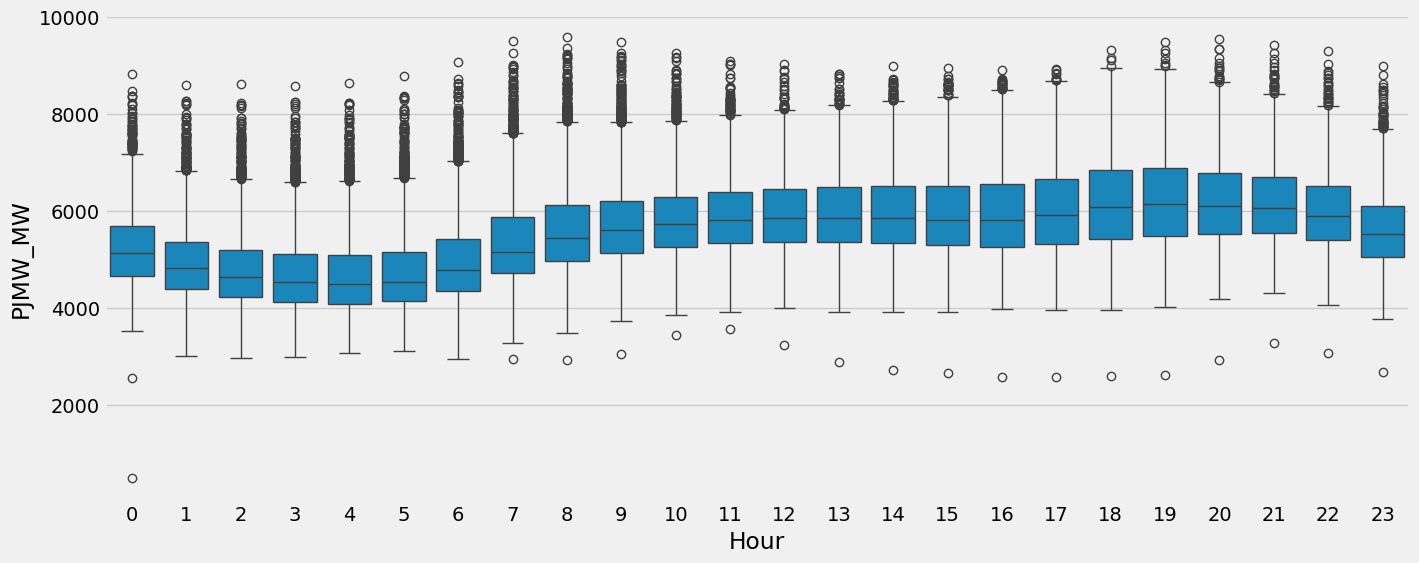

In [54]:
fig, ax=plt.subplots(figsize=(15,6))
sns.boxplot(data=df,x='Hour',y='PJMW_MW',ax=ax)
plt.show()

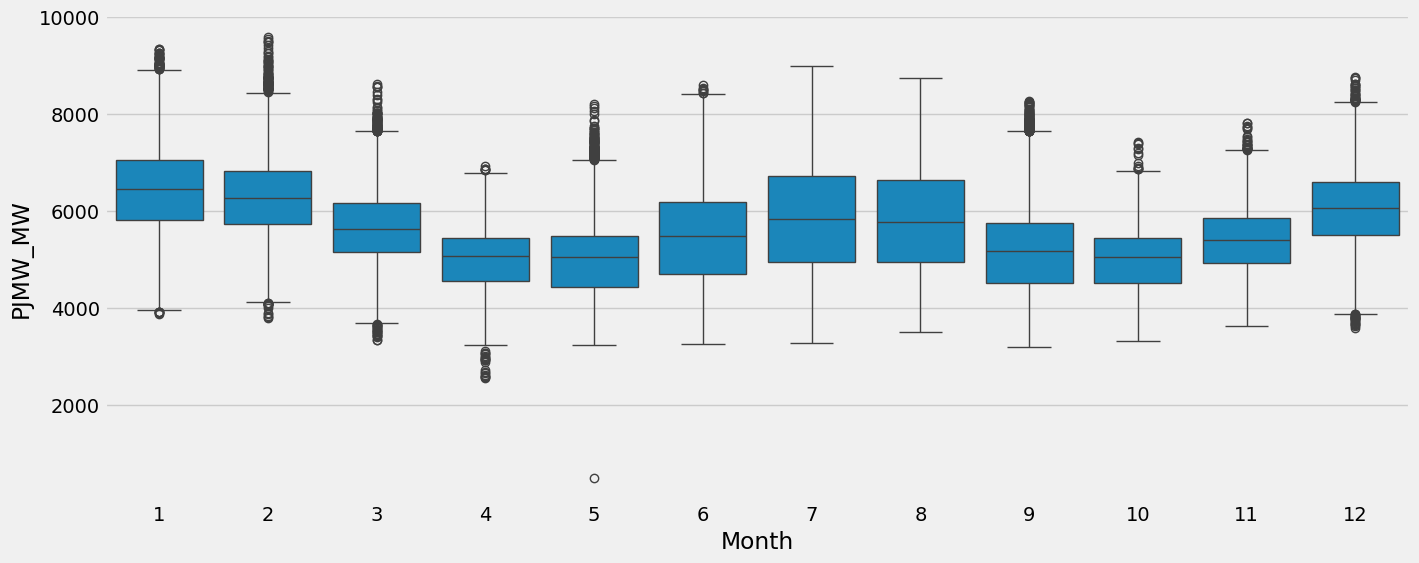

In [55]:
fig, ax=plt.subplots(figsize=(15,6))
sns.boxplot(data=df,x='Month',y='PJMW_MW',ax=ax)
plt.show()

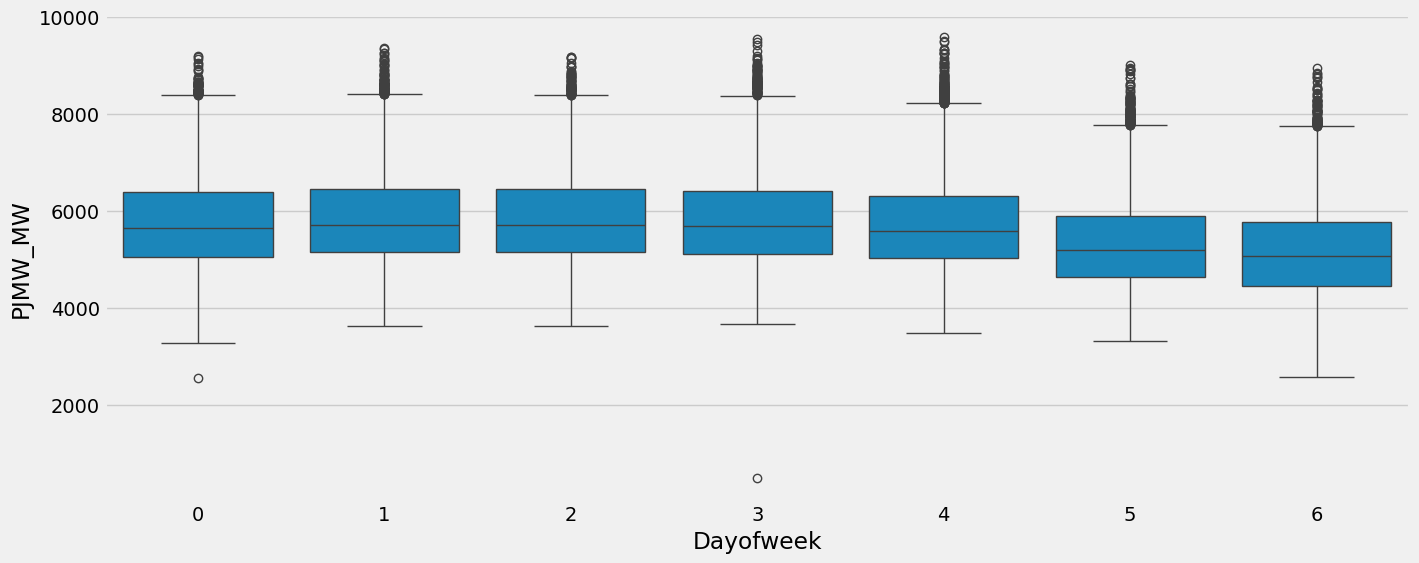

In [56]:
fig, ax=plt.subplots(figsize=(15,6))
sns.boxplot(data=df,x='Dayofweek',y='PJMW_MW',ax=ax)
plt.show()

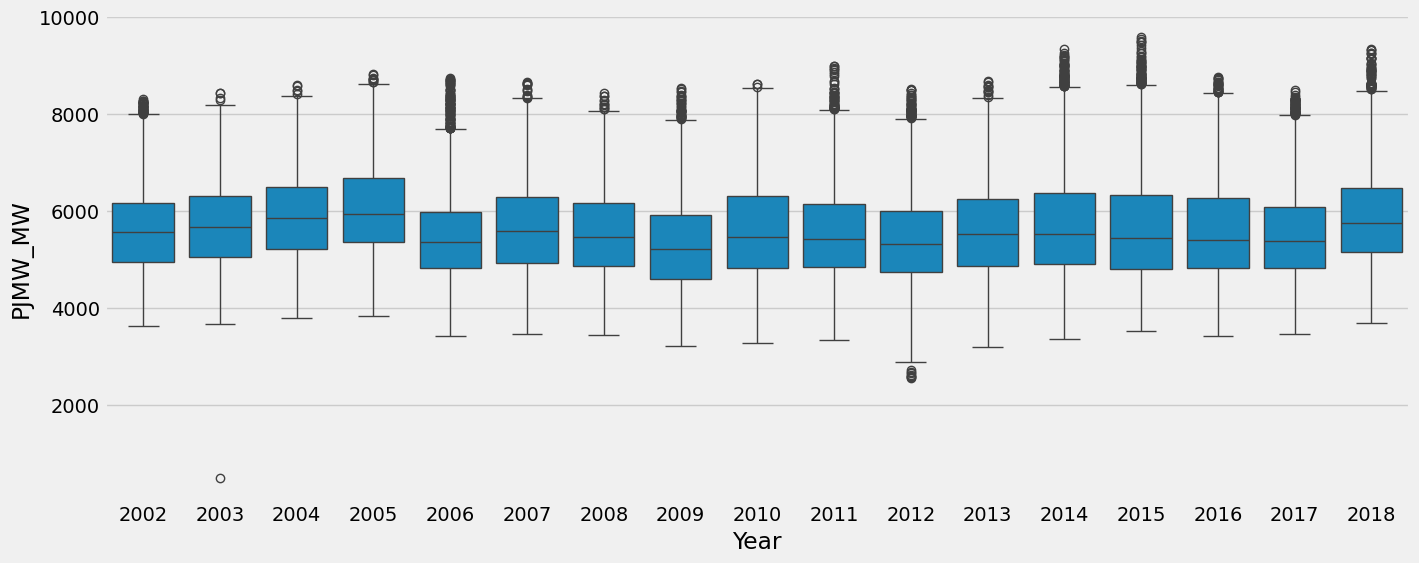

In [57]:
fig, ax=plt.subplots(figsize=(15,6))
sns.boxplot(data=df,x='Year',y='PJMW_MW',ax=ax)
plt.show()

#Model Development

In [58]:
train = Create_Features(train)
test = Create_Features(test)

In [59]:
FEATURES=['Hour', 'Dayofweek', 'Dayofyear', 'Month', 'Quarter',
       'Year']
TARGET='PJMW_MW'
x_train=train[FEATURES]
y_train=train[TARGET]

x_test=test[FEATURES]
y_test=test[TARGET]

In [60]:
from sklearn.metrics import mean_squared_error
reg=xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,
                     learning_rate=0.01)
reg.fit(x_train,y_train,
        eval_set=[(x_train,y_train),(x_test,y_test)],
        verbose=100)

[0]	validation_0-rmse:958.47022	validation_1-rmse:1022.41683
[100]	validation_0-rmse:617.07686	validation_1-rmse:714.08150
[200]	validation_0-rmse:511.79155	validation_1-rmse:657.18813
[300]	validation_0-rmse:468.60207	validation_1-rmse:647.44347
[367]	validation_0-rmse:448.29167	validation_1-rmse:647.73291


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

#Features_Importance

<Axes: title={'center': 'Features Importance'}>

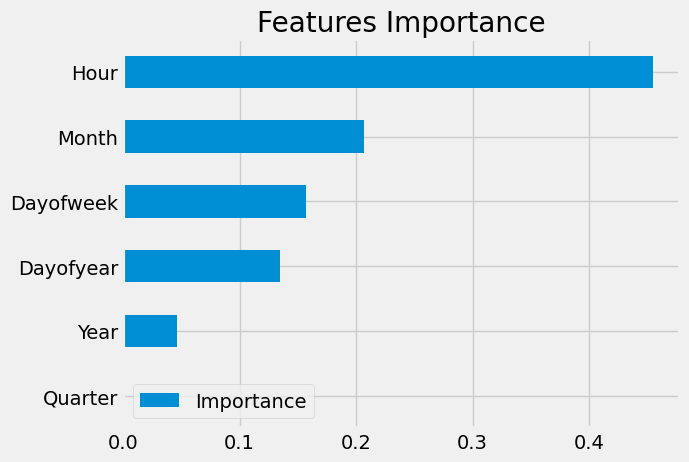

In [61]:
pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['Importance']).sort_values(by='Importance').plot(kind='barh',title='Features Importance')

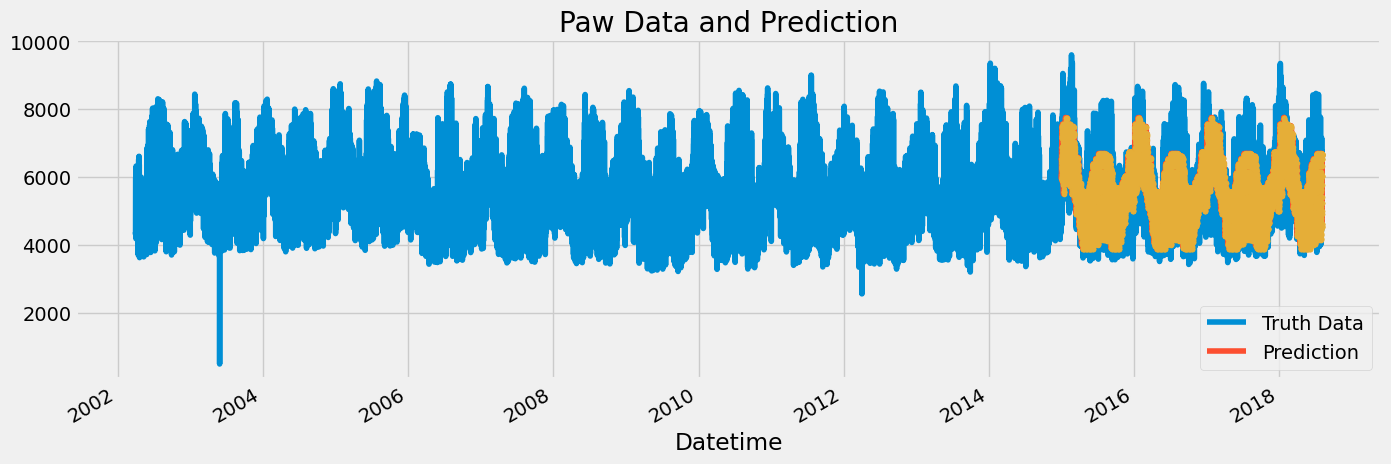

In [62]:
test['Prediction'] = reg.predict(x_test)
df=df.merge(test[['Prediction']], how='left', left_index=True, right_index=True)
ax=df[['PJMW_MW','Prediction']].plot(figsize=(15,5))
df['Prediction'].plot(ax=ax,style='.')
plt.legend(['Truth Data','Prediction'])
ax.set_title('Paw Data and Prediction')
plt.show()

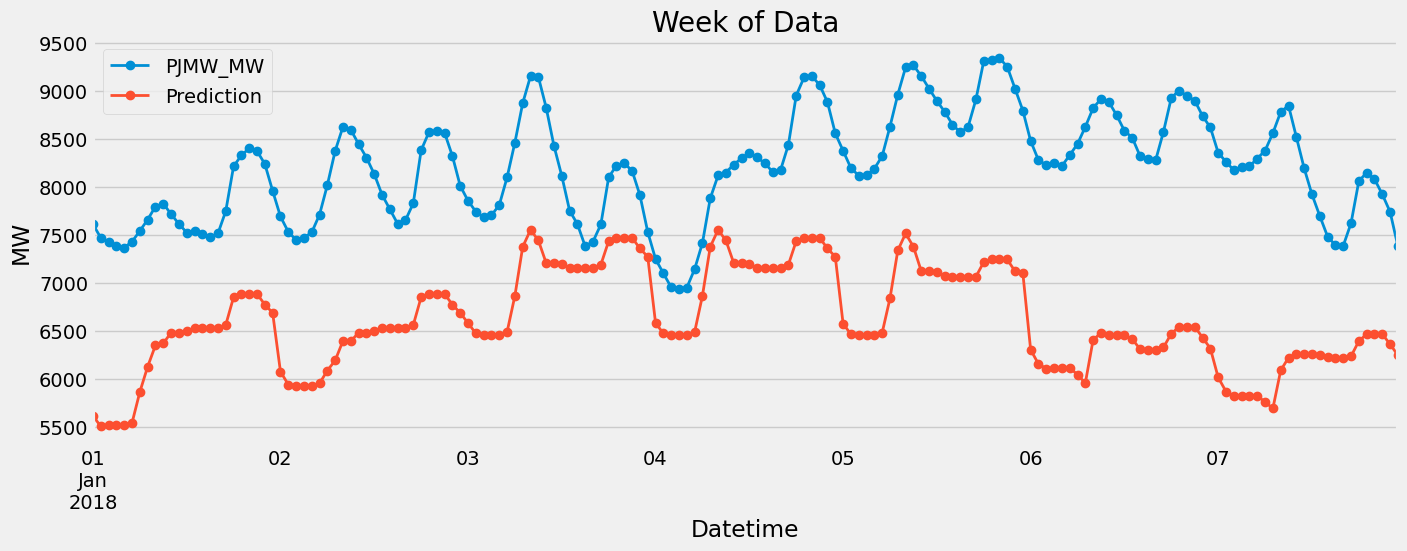

In [63]:
df.index = pd.to_datetime(df.index)
df = df.sort_index() # Sort the index

# Filter date range and select only the two columns
df.loc['2018-01-01':'2018-01-07', ['PJMW_MW', 'Prediction']].plot(
    figsize=(15, 5),
    kind='line',
    title='Week of Data',
    linewidth=2,
    marker='o'
)

plt.ylabel('MW')
plt.grid(True)
plt.show()

In [64]:
import numpy as np
# calculate RMSE
score = np.sqrt(mean_squared_error(test['PJMW_MW'], test['Prediction']))

print(f'RMSE: {score:0.2f}', score)


RMSE: 647.25 647.2518859348623


#worst and Best Predicted Day

In [65]:
test['error']=np.abs(test[TARGET]-test['Prediction'])
test['error']

,error
Datetime,
2015-01-01 00:00:00,290.001953
2015-12-31 01:00:00,811.522461
2015-12-31 02:00:00,872.752930
2015-12-31 03:00:00,956.752930
2015-12-31 04:00:00,917.752930
...,...
2018-01-01 20:00:00,1517.208984
2018-01-01 21:00:00,1489.208984
2018-01-01 22:00:00,1464.520508


<Axes: title={'center': 'Worst Days'}, ylabel='date'>

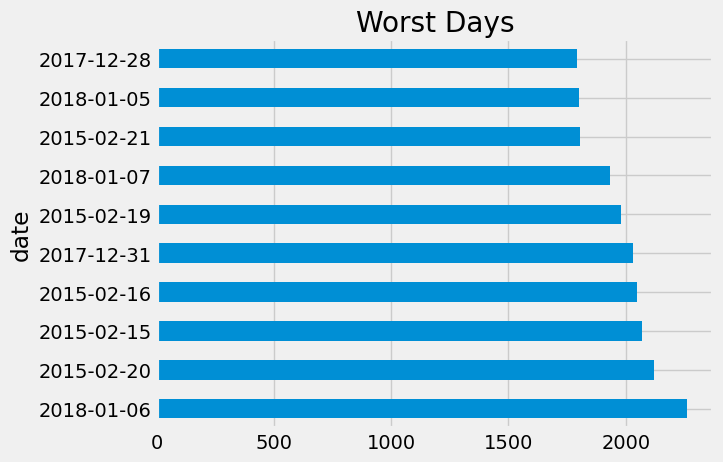

In [66]:
test['date']=test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10).plot(kind='barh',title='Worst Days')

<Axes: title={'center': 'Best Days'}, ylabel='date'>

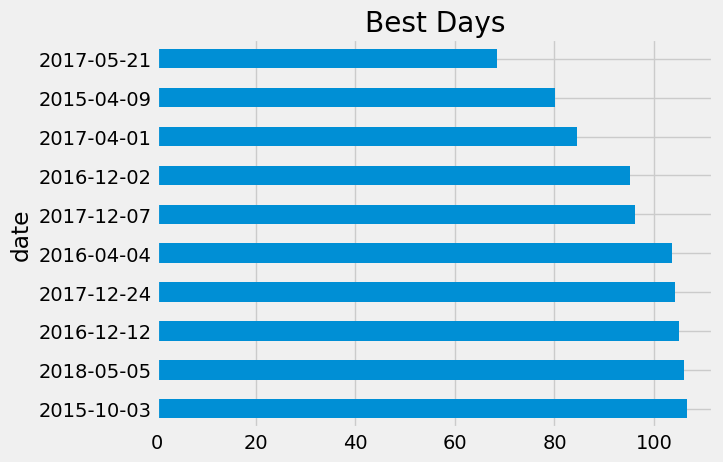

In [67]:
test.groupby(['date'])['error'].mean().sort_values(ascending=False).tail(10).plot(kind='barh',title='Best Days')

#Outline
- Outlier analysis
- Forecasting horizon explained
- Time series cross validation
- Lag Fratures
- Predicting The Future

<Axes: ylabel='Frequency'>

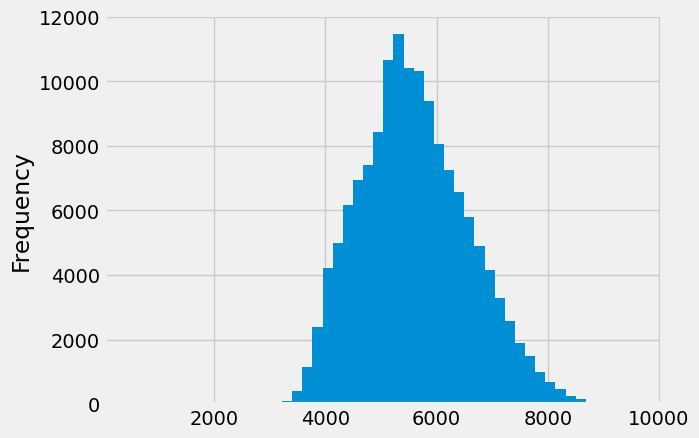

In [68]:
df['PJMW_MW'].plot(kind='hist',bins=50)

In [69]:
df = df.query('PJMW_MW > 3500').copy()

In [70]:
df.query('PJMW_MW < 3500').copy().head()

,PJMW_MW,Hour,Dayofweek,Dayofyear,Month,Quarter,Year,Prediction
Datetime,,,,,,,,


#Advance Algorithm

In [71]:
from sklearn.model_selection import TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5,test_size=24*365*1, gap=24)
df=df.sort_index()

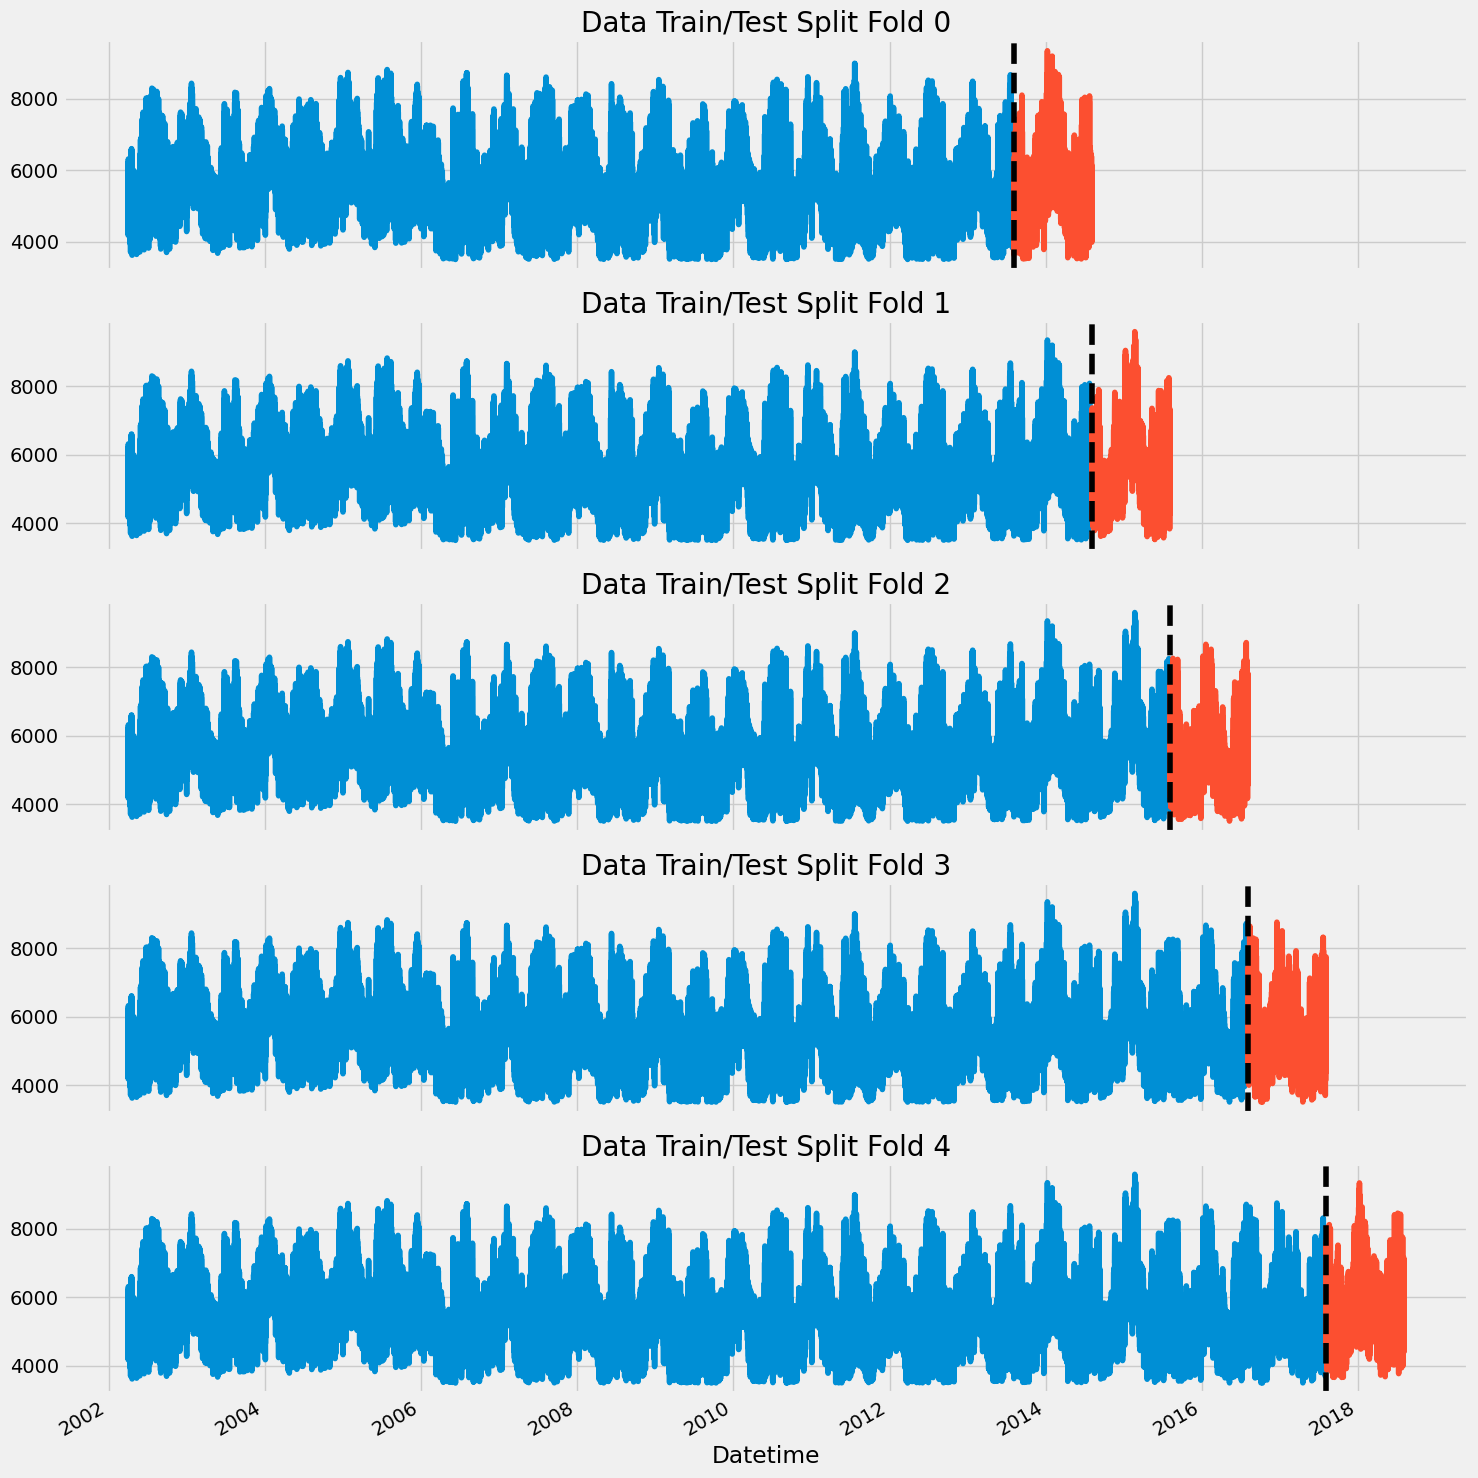

In [72]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)
fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJMW_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJMW_MW'].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.tight_layout()
plt.show()

##Lag_Features

In [73]:
target_map = df['PJMW_MW'].to_dict()

In [83]:
def add_lags(df):
  df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
  df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
  df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
  return df

In [84]:
df=add_lags(df)

In [86]:
df.head(5)

,PJMW_MW,Hour,Dayofweek,Dayofyear,Month,Quarter,Year,Prediction,lag1,lag2,lag3
Datetime,,,,,,,,,,,
2002-04-01 01:00:00,4374.0,1,0,91,4,2,2002,NaN,NaN,NaN,NaN
2002-04-01 02:00:00,4306.0,2,0,91,4,2,2002,NaN,NaN,NaN,NaN
2002-04-01 03:00:00,4322.0,3,0,91,4,2,2002,NaN,NaN,NaN,NaN
2002-04-01 04:00:00,4359.0,4,0,91,4,2,2002,NaN,NaN,NaN,NaN
2002-04-01 05:00:00,4436.0,5,0,91,4,2,2002,NaN,NaN,NaN,NaN


In [90]:
# Time series split
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

fold = 0
preds = []
scores = []

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = Create_Features(train)
    test = Create_Features(test)

    FEATURES = ['Hour', 'Dayofweek', 'Dayofyear', 'Month', 'Quarter',
       'Year','lag1', 'lag2', 'lag3']
    TARGET = 'PJMW_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(
        base_score=0.5,
        booster='gbtree',
        n_estimators=1000,
        early_stopping_rounds=50,
        objective='reg:linear',
        max_depth=3,
        learning_rate=0.01
    )

    reg.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100
    )

    y_pred = reg.predict(X_test)
    preds.append(y_pred)

    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)


[0]	validation_0-rmse:5629.94671	validation_1-rmse:5691.08700


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [16:22:07] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:2137.27283	validation_1-rmse:2285.23571
[200]	validation_0-rmse:941.68132	validation_1-rmse:1120.15965
[300]	validation_0-rmse:606.32765	validation_1-rmse:771.30677
[400]	validation_0-rmse:529.78307	validation_1-rmse:675.50821
[500]	validation_0-rmse:507.32153	validation_1-rmse:645.81504
[600]	validation_0-rmse:495.16482	validation_1-rmse:634.04629
[700]	validation_0-rmse:486.71134	validation_1-rmse:630.64520
[792]	validation_0-rmse:480.76280	validation_1-rmse:630.57835
[0]	validation_0-rmse:5634.88965	validation_1-rmse:5764.67927


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [16:22:16] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:2140.42955	validation_1-rmse:2343.62371
[200]	validation_0-rmse:946.93806	validation_1-rmse:1163.13732
[300]	validation_0-rmse:614.03370	validation_1-rmse:762.21910
[400]	validation_0-rmse:538.65396	validation_1-rmse:648.05858
[500]	validation_0-rmse:516.95837	validation_1-rmse:613.29549
[600]	validation_0-rmse:505.93409	validation_1-rmse:600.14045
[700]	validation_0-rmse:498.75362	validation_1-rmse:592.58774
[800]	validation_0-rmse:493.09513	validation_1-rmse:587.97790
[900]	validation_0-rmse:488.53149	validation_1-rmse:585.73904
[999]	validation_0-rmse:484.52029	validation_1-rmse:583.86532
[0]	validation_0-rmse:5644.40403	validation_1-rmse:5470.14224


...

[100]	validation_0-rmse:2145.53432	validation_1-rmse:1996.93805
[200]	validation_0-rmse:950.86745	validation_1-rmse:838.19826
[300]	validation_0-rmse:618.41890	validation_1-rmse:620.24384
[364]	validation_0-rmse:559.62142	validation_1-rmse:627.48958
[0]	validation_0-rmse:5632.44282	validation_1-rmse:5556.75884


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [16:22:31] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:2141.91347	validation_1-rmse:2144.64665
[200]	validation_0-rmse:953.39941	validation_1-rmse:1007.76511
[300]	validation_0-rmse:625.31939	validation_1-rmse:734.04942
[400]	validation_0-rmse:552.10334	validation_1-rmse:689.79576
[498]	validation_0-rmse:530.94424	validation_1-rmse:687.04867
[0]	validation_0-rmse:5627.51804	validation_1-rmse:5730.82869


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [16:22:36] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:2141.67186	validation_1-rmse:2303.68592
[200]	validation_0-rmse:957.59390	validation_1-rmse:1127.26279
[300]	validation_0-rmse:632.75048	validation_1-rmse:785.07626
[400]	validation_0-rmse:559.87194	validation_1-rmse:697.72694
[500]	validation_0-rmse:539.53464	validation_1-rmse:674.56234
[600]	validation_0-rmse:529.67631	validation_1-rmse:671.38993
[650]	validation_0-rmse:525.97423	validation_1-rmse:672.55014


In [91]:
scores

[np.float64(630.0182167275274),
 np.float64(583.7845838842888),
 np.float64(618.4879358410458),
 np.float64(685.6748424044094),
 np.float64(671.3899267260822)]

In [93]:
print(f'score across folda {np.mean(scores):0.2f}')
print(f'Fold scores: {scores}')

score across folda 637.87
Fold scores: [np.float64(630.0182167275274), np.float64(583.7845838842888), np.float64(618.4879358410458), np.float64(685.6748424044094), np.float64(671.3899267260822)]


##Predict Future

In [95]:
# Retrain on all data
df = Create_Features(df)

FEATURES = ['Hour', 'Dayofweek', 'Dayofyear', 'Month', 'Quarter',
       'Year','lag1', 'lag2', 'lag3']
TARGET = 'PJMW_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=500,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)


[0]	validation_0-rmse:5633.90512


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [16:31:12] WARNING: /workspace/src/objective/regression_obj.cu:245: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:2144.94697
[200]	validation_0-rmse:960.60644
[300]	validation_0-rmse:638.39624
[400]	validation_0-rmse:566.80483
[499]	validation_0-rmse:546.32557


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [96]:
df.tail()

,PJMW_MW,Hour,Dayofweek,Dayofyear,Month,Quarter,Year,Prediction,lag1,lag2,lag3
Datetime,,,,,,,,,,,
2018-08-02 20:00:00,6545.0,20,3,214,8,3,2018,6631.295898,7175.0,6987.0,5584.0
2018-08-02 21:00:00,6496.0,21,3,214,8,3,2018,6631.295898,6957.0,6802.0,5637.0
2018-08-02 22:00:00,6325.0,22,3,214,8,3,2018,6537.901855,6770.0,6660.0,5513.0
2018-08-02 23:00:00,5892.0,23,3,214,8,3,2018,6030.306152,6207.0,6162.0,5164.0
2018-08-03 00:00:00,5489.0,0,4,215,8,3,2018,5240.666992,5713.0,5620.0,4772.0


In [103]:
from operator import add
future=pd.date_range('2018-08-03','2019-08-01',freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] =True
df['isFuture'] = False
df=pd.concat([df,future_df])
df_and_future = pd.concat([df, future_df])
df_and_future = Create_Features(df_and_future)
df_and_future = add_lags(df_and_future)

In [104]:
df_and_future

,PJMW_MW,Hour,Dayofweek,Dayofyear,Month,Quarter,Year,Prediction,lag1,lag2,lag3,isFuture
2002-04-01 01:00:00,4374.0,1,0,91,4,2,2002,NaN,NaN,NaN,NaN,False
2002-04-01 02:00:00,4306.0,2,0,91,4,2,2002,NaN,NaN,NaN,NaN,False
2002-04-01 03:00:00,4322.0,3,0,91,4,2,2002,NaN,NaN,NaN,NaN,False
2002-04-01 04:00:00,4359.0,4,0,91,4,2,2002,NaN,NaN,NaN,NaN,False
2002-04-01 05:00:00,4436.0,5,0,91,4,2,2002,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31 20:00:00,NaN,20,2,212,7,3,2019,NaN,6816.0,7240.0,6951.0,True
2019-07-31 21:00:00,NaN,21,2,212,7,3,2019,NaN,6571.0,6970.0,6864.0,True
2019-07-31 22:00:00,NaN,22,2,212,7,3,2019,NaN,6362.0,6697.0,6670.0,True
2019-07-31 23:00:00,NaN,23,2,212,7,3,2019,NaN,5881.0,6250.0,6162.0,True


In [106]:
future_w_features = df_and_future.query('isFuture').copy()

In [107]:
future_w_features['Prediction'] = reg.predict(future_w_features[FEATURES])

<Axes: title={'center': 'Future Predictions'}>

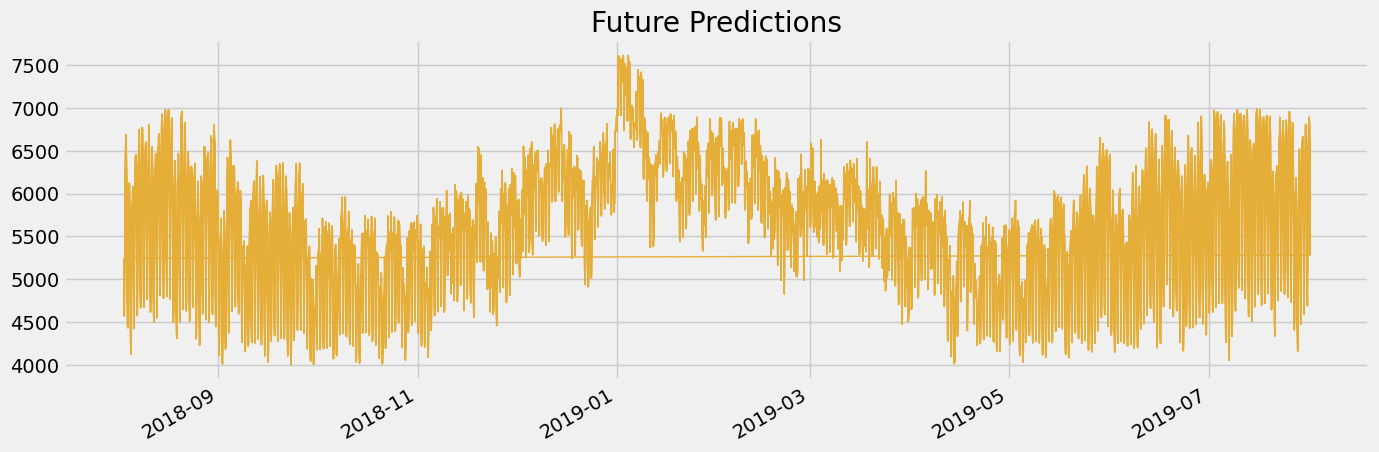

In [111]:
future_w_features['Prediction'].plot(figsize=(15,5),color=color_pal[2],ms=1,lw=1,title='Future Predictions')

##Saving Model for Later

In [116]:
#save model
reg.save_model('model.json')

In [117]:
!ls -lh

total 564K
drwx------ 5 root root 4.0K Aug 17 14:57 drive
-rw-r--r-- 1 root root 555K Aug 17 16:54 model.json
drwxr-xr-x 1 root root 4.0K Aug 14 13:36 sample_data


<Axes: title={'center': 'Future Predictions'}>

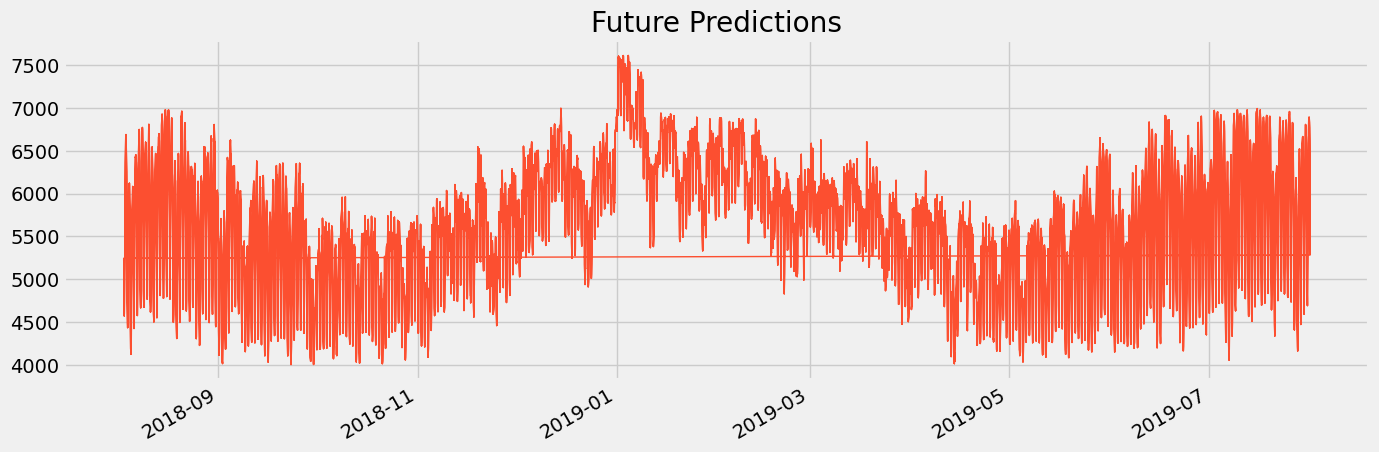

In [119]:
reg_new = xgb.XGBRegressor()
reg_new.load_model('model.json')
future_w_features['Prediction'].plot(figsize=(15,5),
                                     color=color_pal[1],
                                     ms=1,
                                     lw=1,
                                     title='Future Predictions')

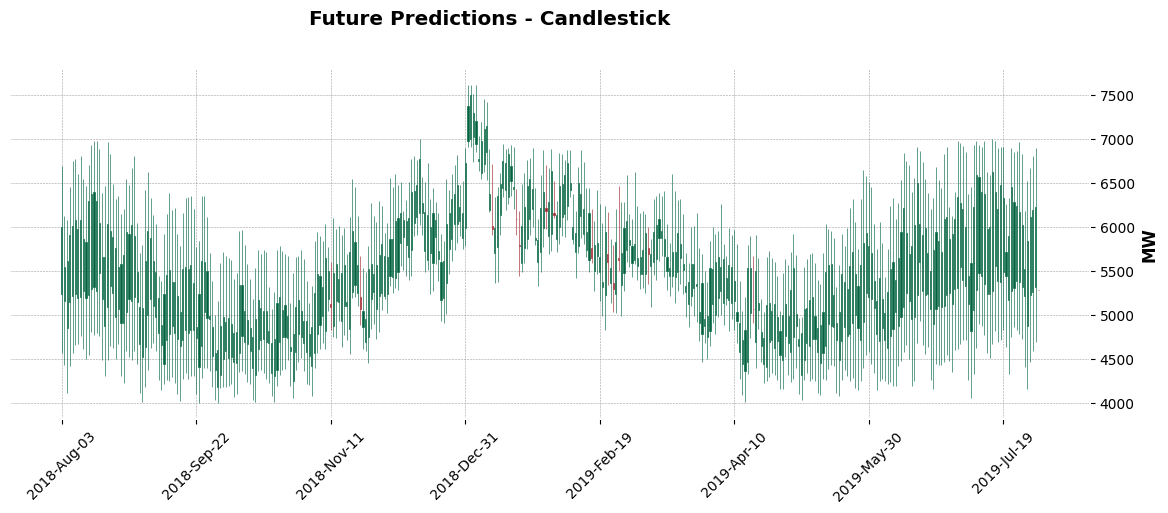

In [122]:
import mplfinance as mpf

# Resample to daily OHLC (you can change 'D' to 'H' for hourly, 'W' for weekly, etc.)
ohlc = future_w_features['Prediction'].resample('D').ohlc()

# Plot candlestick chart
mpf.plot(ohlc,
         type='candle',
         style='charles',
         title='Future Predictions - Candlestick',
         ylabel='MW',
         figsize=(15,5))


In [121]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.8 MB/s eta 0:00:00
